In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
  PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DIR, PROCESSED_DIR

(WindowsPath('c:/uni/seriousism/Redshifted/data/raw'),
 WindowsPath('c:/uni/seriousism/Redshifted/data/processed'))

In [5]:
csv_files = sorted(RAW_DIR.glob("*.csv"))

for file in csv_files:
  size_mb = file.stat().st_size / (1024 * 1024)
  print(f"{file.name} - {size_mb:.2f} MB")

Skyserver_SQL7_Galaxy_50k.csv - 6.52 MB
Skyserver_SQL7_QSO_50k.csv - 6.30 MB
Skyserver_SQL7_Star_50k.csv - 6.55 MB


In [6]:
SELECTED_FILES = [
    "Skyserver_SQL7_Galaxy_50k.csv",
    "Skyserver_SQL7_QSO_50k.csv",
    "Skyserver_SQL7_Star_50k.csv",
]

In [17]:
with open(RAW_DIR / "Skyserver_SQL7_Galaxy_50k.csv", "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 5:
            break

#Table1
objID,specObjID,ra,dec,object_class,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z
1237655499736154698,382956909684090880,198.98194,-1.7545365,GALAXY,0.5379699,0.0001711468,0,23.57166,21.05997,19.40754,18.40446,17.84912
1237650762398826607,382957459439904768,198.88858,-1.8089391,GALAXY,0.120826,1.02896E-05,0,18.79226,17.73469,17.16575,16.85046,16.62631
1237655495977599096,382957734317811712,198.88278,-1.5700078,GALAXY,0.1403358,3.029649E-05,0,20.35433,18.1915,17.12941,16.66815,16.31438
1237655499736154685,382958009195718656,198.97587,-1.7967205,GALAXY,0.4882576,0.0001248516,0,22.18442,20.9232,19.10797,18.23481,17.80382
1237655495977599150,382958284073625600,198.9691,-1.5713743,GALAXY,0.1311051,2.108423E-05,0,19.21795,17.49209,16.54273,16.11701,15.81184


In [18]:
dfs = []

for filename in SELECTED_FILES:
    path = RAW_DIR / filename
    temp_df = pd.read_csv(path, skiprows=1)
    temp_df["source_file"] = filename
    dfs.append(temp_df)

df = pd.concat(dfs, ignore_index=True)

df.shape

(150000, 14)

In [19]:
df.head()

,objID,specObjID,ra,dec,object_class,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z,source_file
0,1237655499736154698,382956909684090880,198.98194,-1.754536,GALAXY,0.537970,0.000171,0,23.57166,21.05997,19.40754,18.40446,17.84912,Skyserver_SQL7_Galaxy_50k.csv
1,1237650762398826607,382957459439904768,198.88858,-1.808939,GALAXY,0.120826,0.000010,0,18.79226,17.73469,17.16575,16.85046,16.62631,Skyserver_SQL7_Galaxy_50k.csv
2,1237655495977599096,382957734317811712,198.88278,-1.570008,GALAXY,0.140336,0.000030,0,20.35433,18.19150,17.12941,16.66815,16.31438,Skyserver_SQL7_Galaxy_50k.csv
3,1237655499736154685,382958009195718656,198.97587,-1.796720,GALAXY,0.488258,0.000125,0,22.18442,20.92320,19.10797,18.23481,17.80382,Skyserver_SQL7_Galaxy_50k.csv
4,1237655495977599150,382958284073625600,198.96910,-1.571374,GALAXY,0.131105,0.000021,0,19.21795,17.49209,16.54273,16.11701,15.81184,Skyserver_SQL7_Galaxy_50k.csv


In [21]:
df.tail()

,objID,specObjID,ra,dec,object_class,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z,source_file
149995,1237655129847824462,1103403115090044928,261.06378,27.470564,STAR,-0.000129,0.000010,0,16.79313,15.68012,15.38801,15.29990,15.31767,Skyserver_SQL7_Star_50k.csv
149996,1237655473975526476,1103405039235393536,260.34213,27.037499,STAR,0.000027,0.000019,0,23.43071,21.55454,20.20011,18.27764,17.29033,Skyserver_SQL7_Star_50k.csv
149997,1237655473975459978,1103407238258649088,260.27535,27.143476,STAR,0.000343,0.000011,0,17.16151,16.12525,15.80575,15.68638,15.66405,Skyserver_SQL7_Star_50k.csv
149998,1237655502427979969,1103408337770276864,260.46239,27.063600,STAR,0.000044,0.000023,0,18.68175,17.58081,17.19257,17.12844,17.04316,Skyserver_SQL7_Star_50k.csv
149999,1237655473975591051,1103408887526090752,260.31339,26.839920,STAR,-0.001159,0.000031,0,18.00508,16.76459,16.73541,16.76009,16.78450,Skyserver_SQL7_Star_50k.csv


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   objID         150000 non-null  int64  
 1   specObjID     150000 non-null  uint64 
 2   ra            150000 non-null  float64
 3   dec           150000 non-null  float64
 4   object_class  150000 non-null  str    
 5   z             150000 non-null  float64
 6   zErr          150000 non-null  float64
 7   zWarning      150000 non-null  int64  
 8   dered_u       150000 non-null  float64
 9   dered_g       150000 non-null  float64
 10  dered_r       150000 non-null  float64
 11  dered_i       150000 non-null  float64
 12  dered_z       150000 non-null  float64
 13  source_file   150000 non-null  str    
dtypes: float64(9), int64(2), str(2), uint64(1)
memory usage: 20.6 MB


In [23]:
df.columns = df.columns.str.strip()

if "class" in df.columns and "object_class" not in df.columns:
    df = df.rename(columns={"class": "object_class"})

df.columns.tolist()

['objID',
 'specObjID',
 'ra',
 'dec',
 'object_class',
 'z',
 'zErr',
 'zWarning',
 'dered_u',
 'dered_g',
 'dered_r',
 'dered_i',
 'dered_z',
 'source_file']

In [26]:
temp = pd.read_csv(RAW_DIR / "Skyserver_SQL7_Galaxy_50k.csv", nrows=5, skiprows=1)
print(temp.columns.tolist())

['objID', 'specObjID', 'ra', 'dec', 'object_class', 'z', 'zErr', 'zWarning', 'dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z']


In [28]:
required_cols = [
    "objID",
    "specObjID",
    "ra",
    "dec",
    "object_class",
    "z",
    "zErr",
    "zWarning",
    "dered_u",
    "dered_g",
    "dered_r",
    "dered_i",
    "dered_z",
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")
else:
    print("All required columns are available.")

All required columns are available.


In [31]:
df.describe()

,objID,specObjID,ra,dec,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z
count,1.500000e+05,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.0,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,1.237660e+18,4.000743e+18,168.115660,21.346183,0.598483,0.017942,0.0,20.891240,19.753083,19.100314,18.687683,18.448595
std,9.672938e+12,4.008666e+18,90.578995,23.969265,0.794052,1.093270,0.0,2.131883,2.027259,1.923762,1.843373,1.870465
min,1.237646e+18,2.994897e+17,0.005356,-10.961061,-0.004663,-6.000000,0.0,11.848150,12.283450,9.958602,9.084468,10.566780
25%,1.237652e+18,4.392450e+17,125.487265,0.045921,0.000083,0.000017,0.0,19.303133,18.135840,17.442523,17.075153,16.826815
50%,1.237658e+18,8.974293e+17,180.343630,6.148424,0.139906,0.000052,0.0,20.569945,19.709185,19.193920,18.855255,18.594600
75%,1.237665e+18,8.658205e+18,220.947008,47.097584,1.047240,0.000285,0.0,22.258823,21.317097,20.737590,20.248115,19.902165
max,1.237680e+18,9.873242e+18,359.993220,68.570352,7.011245,236.059400,0.0,29.686320,29.920600,29.202880,28.219460,27.499240


In [36]:
df["object_class"].value_counts()

object_class
GALAXY    50000
QSO       50000
STAR      50000
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


Text(0, 0.5, 'Count')

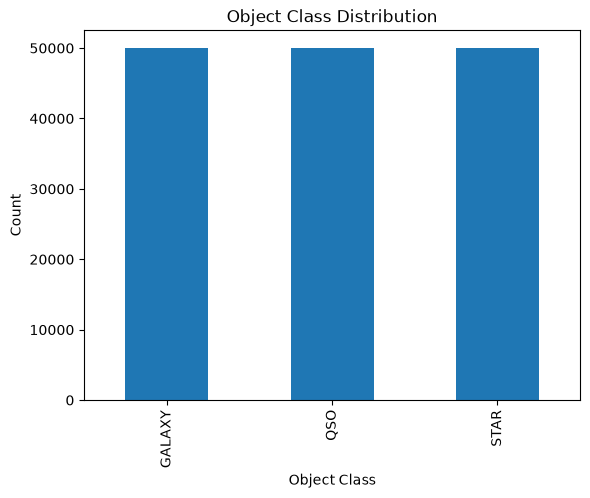

In [37]:
class_counts = df["object_class"].value_counts()

ax = class_counts.plot(kind="bar", title="Object Class Distribution")
ax.set_xlabel("Object Class")
ax.set_ylabel("Count")

In [39]:
df.isnull().sum()

objID           0
specObjID       0
ra              0
dec             0
object_class    0
z               0
zErr            0
zWarning        0
dered_u         0
dered_g         0
dered_r         0
dered_i         0
dered_z         0
source_file     0
dtype: int64

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df["objID"].duplicated().sum()

np.int64(0)

In [42]:
df["specObjID"].duplicated().sum()

np.int64(0)

In [44]:
numeric_cols = [
    "ra", "dec", "z", "zErr", "zWarning",
    "dered_u", "dered_g", "dered_r", "dered_i", "dered_z"
]

df[numeric_cols].describe()

,ra,dec,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.0,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,168.115660,21.346183,0.598483,0.017942,0.0,20.891240,19.753083,19.100314,18.687683,18.448595
std,90.578995,23.969265,0.794052,1.093270,0.0,2.131883,2.027259,1.923762,1.843373,1.870465
min,0.005356,-10.961061,-0.004663,-6.000000,0.0,11.848150,12.283450,9.958602,9.084468,10.566780
25%,125.487265,0.045921,0.000083,0.000017,0.0,19.303133,18.135840,17.442523,17.075153,16.826815
50%,180.343630,6.148424,0.139906,0.000052,0.0,20.569945,19.709185,19.193920,18.855255,18.594600
75%,220.947008,47.097584,1.047240,0.000285,0.0,22.258823,21.317097,20.737590,20.248115,19.902165
max,359.993220,68.570352,7.011245,236.059400,0.0,29.686320,29.920600,29.202880,28.219460,27.499240


In [45]:
print("zWarning values:")
print(df["zWarning"].value_counts())

print("\nObject classes:")
print(df["object_class"].value_counts())

print("\nRA range:", df["ra"].min(), "to", df["ra"].max())
print("DEC range:", df["dec"].min(), "to", df["dec"].max())

zWarning values:
zWarning
0    150000
Name: count, dtype: int64

Object classes:
object_class
GALAXY    50000
QSO       50000
STAR      50000
Name: count, dtype: int64

RA range: 0.0053559968 to 359.99322
DEC range: -10.961061 to 68.570352


In [46]:
mag_cols = ["dered_u", "dered_g", "dered_r", "dered_i", "dered_z"]

for col in mag_cols:
    invalid_count = ((df[col] < 0) | (df[col] > 30)).sum()
    print(f"{col}: {invalid_count} invalid values")

dered_u: 0 invalid values
dered_g: 0 invalid values
dered_r: 0 invalid values
dered_i: 0 invalid values
dered_z: 0 invalid values


In [47]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DIR / "sdss_base_150k.csv"
df.to_csv(output_path, index=False)

output_path

WindowsPath('c:/uni/seriousism/Redshifted/data/processed/sdss_base_150k.csv')

In [49]:
pd.read_csv(output_path).head()

,objID,specObjID,ra,dec,object_class,z,zErr,zWarning,dered_u,dered_g,dered_r,dered_i,dered_z,source_file
0,1237655499736154698,3.829569e+17,198.98194,-1.754536,GALAXY,0.537970,0.000171,0,23.57166,21.05997,19.40754,18.40446,17.84912,Skyserver_SQL7_Galaxy_50k.csv
1,1237650762398826607,3.829575e+17,198.88858,-1.808939,GALAXY,0.120826,0.000010,0,18.79226,17.73469,17.16575,16.85046,16.62631,Skyserver_SQL7_Galaxy_50k.csv
2,1237655495977599096,3.829577e+17,198.88278,-1.570008,GALAXY,0.140336,0.000030,0,20.35433,18.19150,17.12941,16.66815,16.31438,Skyserver_SQL7_Galaxy_50k.csv
3,1237655499736154685,3.829580e+17,198.97587,-1.796720,GALAXY,0.488258,0.000125,0,22.18442,20.92320,19.10797,18.23481,17.80382,Skyserver_SQL7_Galaxy_50k.csv
4,1237655495977599150,3.829583e+17,198.96910,-1.571374,GALAXY,0.131105,0.000021,0,19.21795,17.49209,16.54273,16.11701,15.81184,Skyserver_SQL7_Galaxy_50k.csv


#### Data Check Summary

Combined 150k objects (50k each: GALAXY/STAR/QSO) from the 3 SDSS DR18 files.
No missing values, no duplicate `objID`/`specObjID`, `zWarning == 0` across the board,
and all dereddened magnitudes fall within 0–30.

Note: a few STAR rows have small negative `z` values, this is radial velocity, not
cosmological redshift, since redshift isn't really meaningful for stars. Not an error,
just something to keep in mind when filtering by `z` in the next notebook.

Saved to `data/processed/sdss_base_150k.csv`, ready for cleaning + feature engineering.